# handling DEM as input to WWFS #

In [91]:
import numpy as np
import rasterio
import geopandas as gpd
from rasterio.enums import Resampling
from rasterio.transform import from_origin, Affine
from rasterio.mask import mask
from rasterio.plot import show
import geopandas as gpd
from scipy.interpolate import griddata
from osgeo import gdal, gdalconst
import xdem
import matplotlib.pyplot as plt
from xdem.coreg.workflows import dem_coregistration
import os
from shapely.geometry import box
import rioxarray





In [3]:
datadir_in = "/scratch-3/cogier/data/DEM_input"
datadir_out = "/scratch-3/cogier/data/DEM_output"

### import bedrock in Swiss coordinates ###

/home/cogier/miniconda3/envs/xdem/lib/python3.12/site-packages/geoutils/raster/raster.py:1739: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


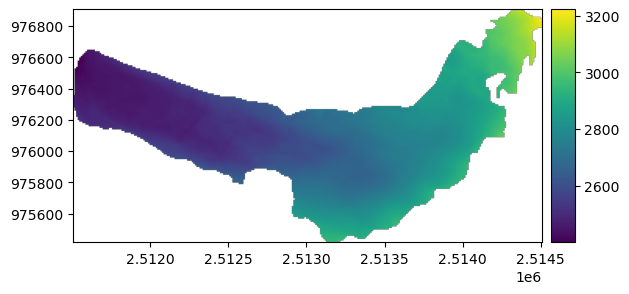

In [4]:
bed_lv95 = xdem.DEM(os.path.join(datadir_in, "grid_bedrock_10m.tif"))
bed_ige = xdem.DEM(os.path.join(datadir_in, "Bedrock.tif"))
bed_lv95.plot()


### Reprojection Swiss to Lambert 93 ###

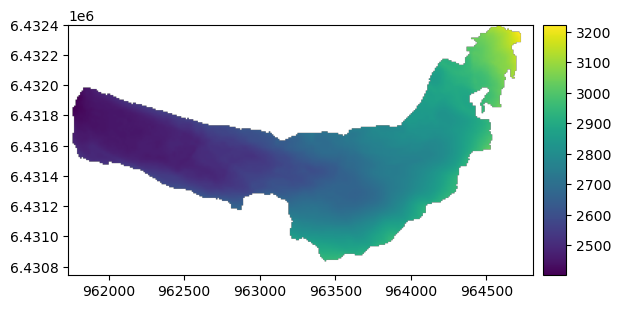

In [5]:
bed = bed_lv95.reproject(crs='EPSG:2154')
bed.save(os.path.join(datadir_out, "Bedrock_reproj.tif"))
bed.plot()

### coregistration to fit Lambert outline (a.k.a ige dem) ###

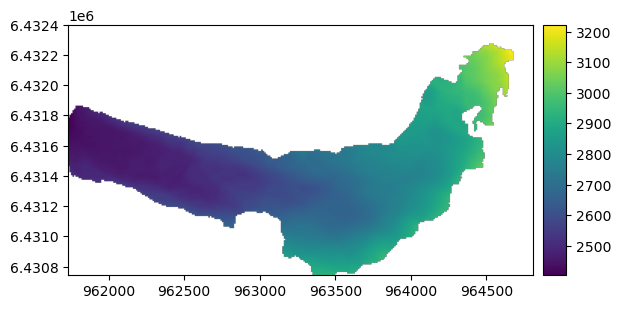

In [6]:
coreg_method = xdem.coreg.NuthKaab()
coreg_method.fit(reference_elev=bed_ige, to_be_aligned_elev=bed)
bed_aligned = coreg_method.apply(bed)
bed_aligned.plot()
bed_aligned.save(os.path.join(datadir_out, "Bedrock_reproj_aligned.tif"))

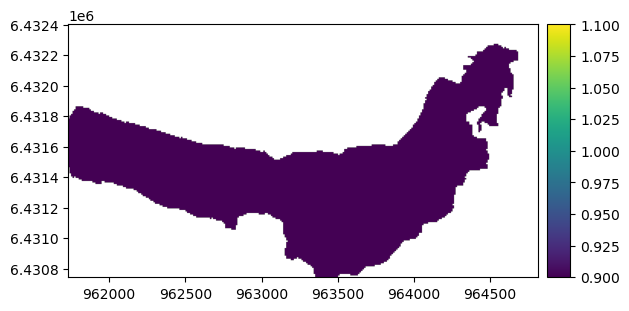

In [69]:
bed_mask = bed_aligned > 0
bed_mask.plot()

In [87]:
bed_shape = rasterio.features.shapes(bed_mask)
bed_shape



<generator object shapes at 0x7f64afffec40>

[961733.7923875334, 6430742.553508839, 964810.505893689, 6432400.782216702]

## Import surface DEMs (and crop) ##

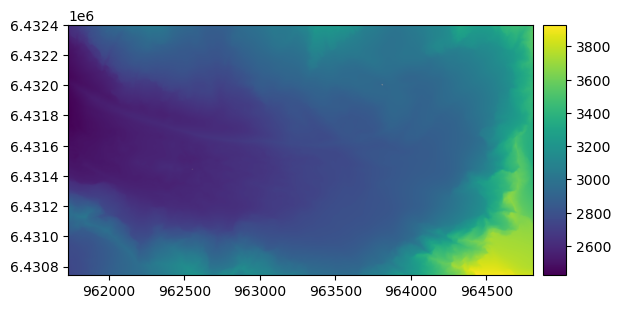

In [121]:
surf_21 = rioxarray.open_rasterio(os.path.join(datadir_in, "Berarde_Res1.0_CompElevmean_merged.tif"),chunks="auto")
list(bed_aligned.bounds)
surf_21_cropp = surf_21.rio.clip_box(961733.7923875334, 6430742.553508839, 964810.505893689, 6432400.782216702)
surf_21_cropp.rio.to_raster(os.path.join(datadir_out, "Berarde_Res1.0_crop.tif"))
surf_21_crop = xdem.DEM(os.path.join(datadir_out, "Berarde_Res1.0_crop.tif"))
surf_21_crop.plot()



AttributeError: 'numpy.ndarray' object has no attribute 'save'